# Compresión de modelos basados en ML

### Imports

In [1]:
import os
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

## Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.models import *
from keras.layers import *
from keras.utils import to_categorical
from keras.optimizers import SGD, Adam
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

## Quantization
from qkeras import *

## Datasets
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist

from distillationClassKeras import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
fig_path = './figs/MNIST'

models_dir = '/Users/denisegayet/Documents/Cursos/UNMDP/ml_fpga_unmdp/labs/lab1/models/' 
model = load_model(models_dir+'mnistModel_FC_vanilla.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 219,818
Trainable params: 219,818
Non-trainable params: 0
_________________________________________________________________


In [33]:
# dataset loading
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

w = x_train_norm.shape[1]
h = x_train_norm.shape[2]

# classes
n_classes = 10

model= Sequential([

    Flatten(input_shape=(w, h)),
    Dense(20, activation='relu'),
    Dense(n_classes, activation='softmax')

])

In [34]:
classes, counts = np.unique(y_train, return_counts=True)
n_classes = len(classes)
in_shape = (x_train_norm.shape[1], x_train_norm.shape[2])

print(f"\nDataset input shape: {in_shape}")
print(f"\nOutput classes: {n_classes}")

# one-hot encode labels
y_train_sparse = y_train.copy()
y_train = to_categorical(y_train, num_classes = n_classes)
y_test = to_categorical(y_test, num_classes = n_classes)



Dataset input shape: (28, 28)

Output classes: 10


## Prunning

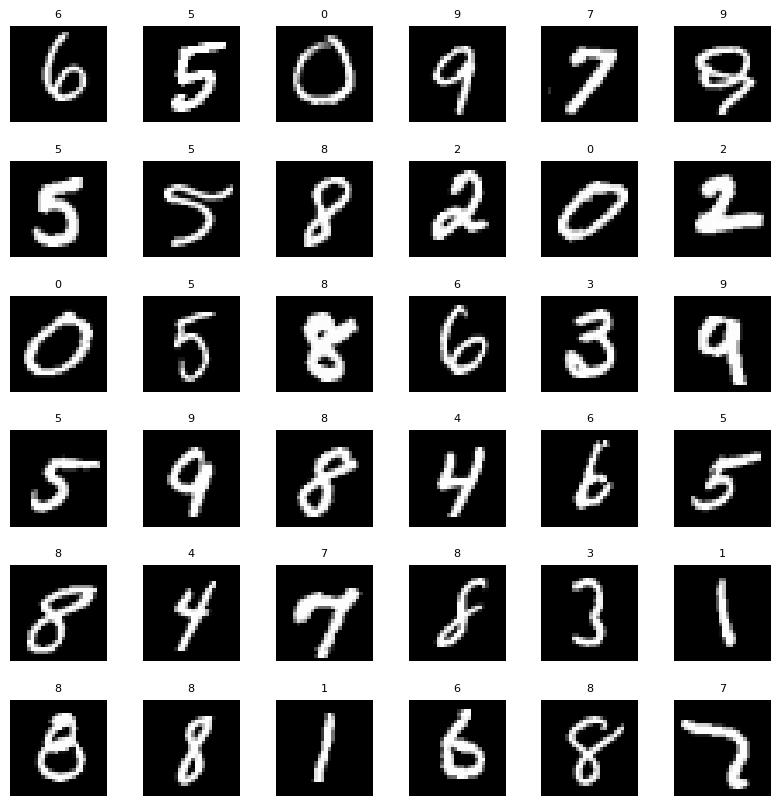

In [35]:
# visualization
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() 
n_train = len(x_train_norm) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train_norm[index], cmap='gray')
    label_index = int(y_train_sparse[index])
    axes[i].set_title(label_index, fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

In [36]:
hparams = {
    'epochs': 50,
    'learning-rate': 0.001,
    'batch-size': 64,
    'val-split': 0.2,
    'loss': 'categorical_crossentropy'
}

op = Adam(hparams['learning-rate'])
final_sparsity = 0.3



In [37]:
model.compile(optimizer=op, loss=hparams['loss'], metrics=['accuracy'])
history_og = model.fit(
                    x_train_norm, y_train,
                    validation_split=hparams['val-split'],
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch-size'],
                    
)

Epoch 1/50
750/750 [==============================] - 1s 639us/step - loss: 0.5040 - accuracy: 0.8620 - val_loss: 0.2772 - val_accuracy: 0.9228
Epoch 2/50
750/750 [==============================] - 0s 550us/step - loss: 0.2673 - accuracy: 0.9233 - val_loss: 0.2351 - val_accuracy: 0.9344
Epoch 3/50
750/750 [==============================] - 0s 554us/step - loss: 0.2269 - accuracy: 0.9341 - val_loss: 0.2178 - val_accuracy: 0.9392
Epoch 4/50
750/750 [==============================] - 0s 568us/step - loss: 0.2024 - accuracy: 0.9418 - val_loss: 0.1979 - val_accuracy: 0.9442
Epoch 5/50
750/750 [==============================] - 0s 594us/step - loss: 0.1862 - accuracy: 0.9462 - val_loss: 0.1891 - val_accuracy: 0.9468
Epoch 6/50
750/750 [==============================] - 1s 675us/step - loss: 0.1731 - accuracy: 0.9496 - val_loss: 0.1865 - val_accuracy: 0.9495
Epoch 7/50
750/750 [==============================] - 1s 687us/step - loss: 0.1615 - accuracy: 0.9532 - val_loss: 0.1733 - val_accuracy:

In [38]:
pruning_params={
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=3000
    )
}

In [39]:
modelP = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)
modelP.compile(optimizer=op, loss=hparams['loss'], metrics=['accuracy'])

In [40]:
history = modelP.fit(
                    x_train_norm, y_train,
                    validation_split=hparams['val-split'],
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch-size'],
                    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
                    verbose=1
)

Epoch 1/50
750/750 [==============================] - 1s 771us/step - loss: 0.0497 - accuracy: 0.9847 - val_loss: 0.1854 - val_accuracy: 0.9553
Epoch 2/50
750/750 [==============================] - 0s 639us/step - loss: 0.0508 - accuracy: 0.9839 - val_loss: 0.1800 - val_accuracy: 0.9564
Epoch 3/50
750/750 [==============================] - 1s 696us/step - loss: 0.0511 - accuracy: 0.9843 - val_loss: 0.1811 - val_accuracy: 0.9558
Epoch 4/50
750/750 [==============================] - 1s 670us/step - loss: 0.0484 - accuracy: 0.9851 - val_loss: 0.1792 - val_accuracy: 0.9555
Epoch 5/50
750/750 [==============================] - 0s 619us/step - loss: 0.0462 - accuracy: 0.9863 - val_loss: 0.1841 - val_accuracy: 0.9543
Epoch 6/50
750/750 [==============================] - 0s 617us/step - loss: 0.0446 - accuracy: 0.9865 - val_loss: 0.1881 - val_accuracy: 0.9542
Epoch 7/50
750/750 [==============================] - 1s 669us/step - loss: 0.0435 - accuracy: 0.9874 - val_loss: 0.1837 - val_accuracy:

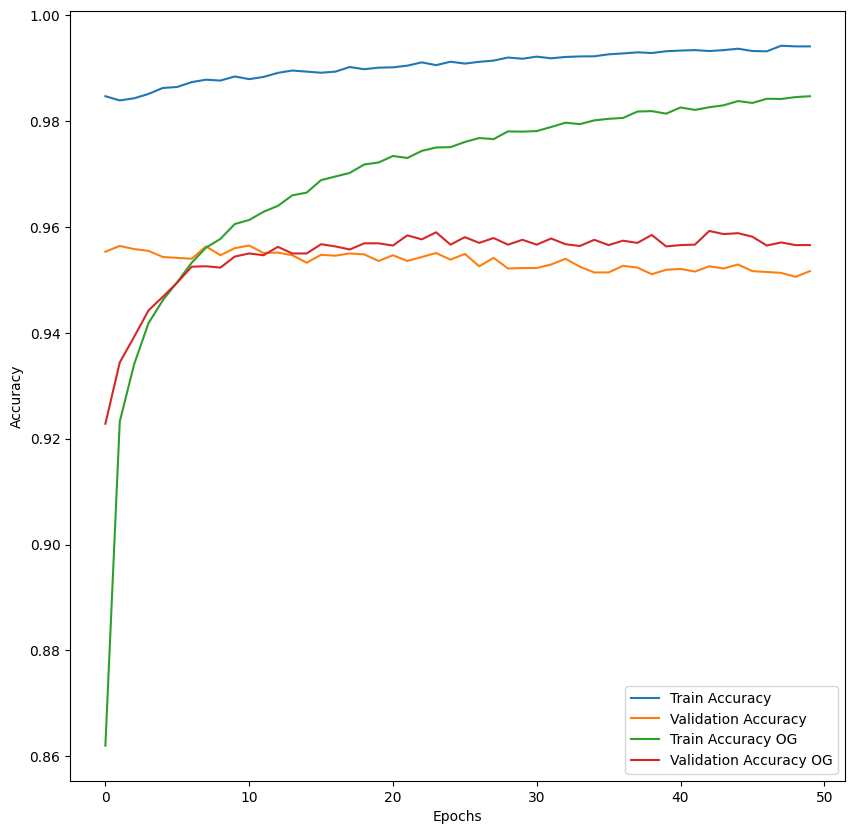

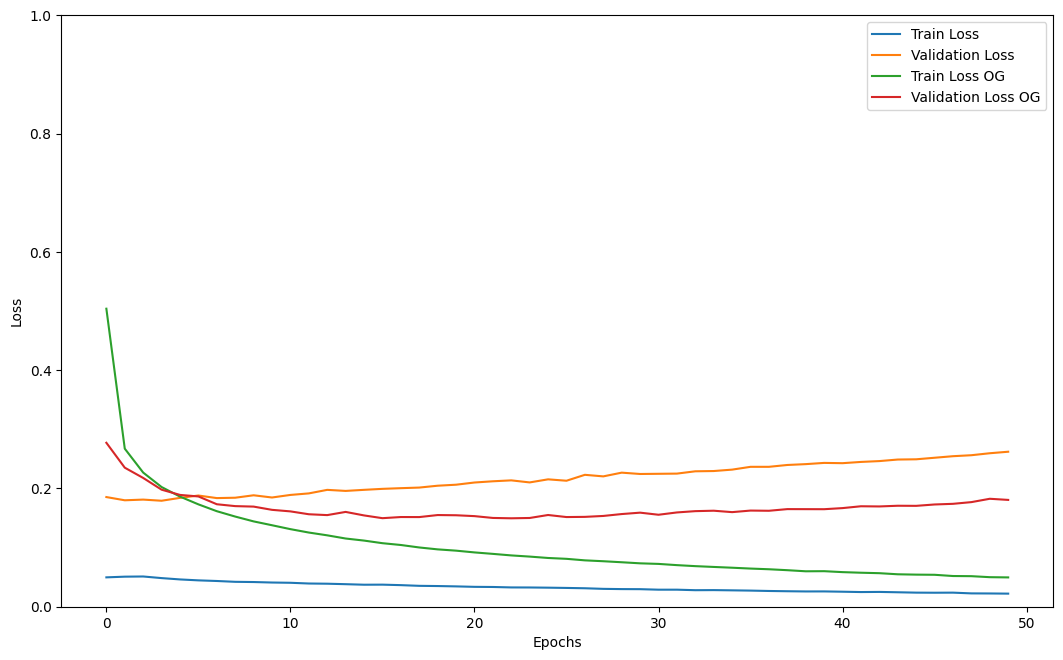

In [41]:
# Plot accuracy over epochs
fig_path = './figs/MNIST'


plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_og.history['accuracy'], label='Train Accuracy OG')
plt.plot(history_og.history['val_accuracy'], label='Validation Accuracy OG')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(10,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history_og.history['loss'], label='Train Loss OG')
plt.plot(history_og.history['val_loss'], label='Validation Loss OG')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0,1)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.show()


In [42]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 20)                15700     
                                                                 
 dense_5 (Dense)             (None, 10)                210       
                                                                 
Total params: 15,910
Trainable params: 15,910
Non-trainable params: 0
_________________________________________________________________


In [43]:
modelP.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_flatten  (None, 784)              1         
 _2 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_4  (None, 20)               31382     
  (PruneLowMagnitude)                                            
                                                                 
 prune_low_magnitude_dense_5  (None, 10)               412       
  (PruneLowMagnitude)                                            
                                                                 
Total params: 31,795
Trainable params: 15,910
Non-trainable params: 15,885
_________________________________________________________________


313/313 [==============================] - 0s 303us/step


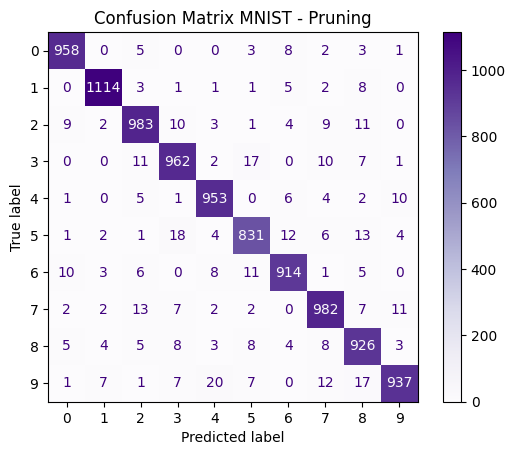

313/313 [==============================] - 0s 340us/step


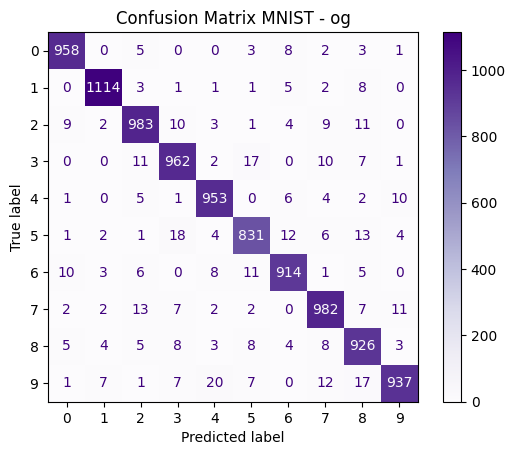

In [50]:
y_pred_probs = modelP.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - Pruning')
plt.show()


y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - og')
plt.show()

In [51]:
modelP = strip_pruning(modelP)
modelP.save('models/mnistModel_FC_P.h5')


####  📝 Ejercicio: 

- Modificar el valor de final_sparsity (0.1, 0.3, 0.5, 0.7, 0.9) y reportar las métricas para cada modelo. Qué conclusión se puede obtener al respecto? 


--- 

A medida que se aumenta el valor de final_sparsity, se aumenta la cantidad de neuronas que se quitan del modelo. Por lo tanto, a mayor final_sparsity, pero es el rendimiento de la red. Con valores pequeños como 0.1 o 0.3, la red puede recuperarse de la perdida de neuronas y mantener el rendimiento. Sin embargo, para valores altos como 0.7 o 0.9, la red pierde capacidad de aprender y reduce su accuracy, dado que es una arquitectura mucho menor.

## Quantization

### QAT: Quantization Aware-Training

Se entrena desde 0 con cuantización (no con el modelo en precisión completa, es decir, fp de 32 bits)

In [78]:
# Estrategia de cuantizacion

# Definicion del numer de bits para kernel, bias, y activacion. 
# 8 bits

m = 12
d = 6

kernelQ = f'quantized_bits({m},{d},alpha=1)'
biasQ = f'quantized_bits({m},{d},alpha=1)'
activationQ = f'quantized_bits({m},{d})'

modelQAT = Sequential([
    Flatten(input_shape=(in_shape)),
    QDense(100, name='fc1',
                        kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                        kernel_initializer='lecun_uniform'),
    QActivation(activation= activationQ ,  name='relu1'),


    QDense(50, name='fc2',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform'),
    QActivation(activation=activationQ, name='relu2'), 
    Dropout(0.1),
    

    QDense(20, name='fc3',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform'),
    QActivation(activation=activationQ, name='relu3'), 
    
    Dropout(0.1),
    
    QDense(10, name='output',
            kernel_quantizer= kernelQ, bias_quantizer= biasQ,
            kernel_initializer='lecun_uniform'),
    Activation(activation='softmax', name='softmax')
],
name="quantizedModel",
)

In [79]:
modelQAT.summary()

Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_8 (Flatten)         (None, 784)               0         
                                                                 
 fc1 (QDense)                (None, 100)               78500     
                                                                 
 relu1 (QActivation)         (None, 100)               0         
                                                                 
 fc2 (QDense)                (None, 50)                5050      
                                                                 
 relu2 (QActivation)         (None, 50)                0         
                                                                 
 dropout_9 (Dropout)         (None, 50)                0         
                                                                 
 fc3 (QDense)                (None, 20)             

In [80]:
hparams={
    'epochs': 16,
    'learning_rate': 0.001,
    'batch_size': 64,
    'val_split' : 0.2,
    'loss' : 'categorical_crossentropy'
}

op = Adam(hparams['learning_rate'])
metrics = ['accuracy']


modelQAT.compile(optimizer=op, loss=hparams['loss'], metrics=metrics)
                
historyQAT = modelQAT.fit(x_train_norm, y_train,
                validation_split = hparams['val_split'],
                epochs=hparams['epochs'],
                batch_size = hparams['batch_size'],
                verbose=1
                )

Epoch 1/16
750/750 [==============================] - 2s 2ms/step - loss: 0.4841 - accuracy: 0.8564 - val_loss: 0.3357 - val_accuracy: 0.9047
Epoch 2/16
750/750 [==============================] - 1s 2ms/step - loss: 0.3720 - accuracy: 0.8944 - val_loss: 0.2987 - val_accuracy: 0.9178
Epoch 3/16
750/750 [==============================] - 1s 1ms/step - loss: 0.3537 - accuracy: 0.8982 - val_loss: 0.2955 - val_accuracy: 0.9179
Epoch 4/16
750/750 [==============================] - 1s 1ms/step - loss: 0.3461 - accuracy: 0.9013 - val_loss: 0.2947 - val_accuracy: 0.9195
Epoch 5/16
750/750 [==============================] - 1s 1ms/step - loss: 0.3357 - accuracy: 0.9053 - val_loss: 0.2887 - val_accuracy: 0.9207
Epoch 6/16
750/750 [==============================] - 1s 1ms/step - loss: 0.3339 - accuracy: 0.9045 - val_loss: 0.2832 - val_accuracy: 0.9211
Epoch 7/16
750/750 [==============================] - 1s 1ms/step - loss: 0.3285 - accuracy: 0.9067 - val_loss: 0.2801 - val_accuracy: 0.9222
Epoch 

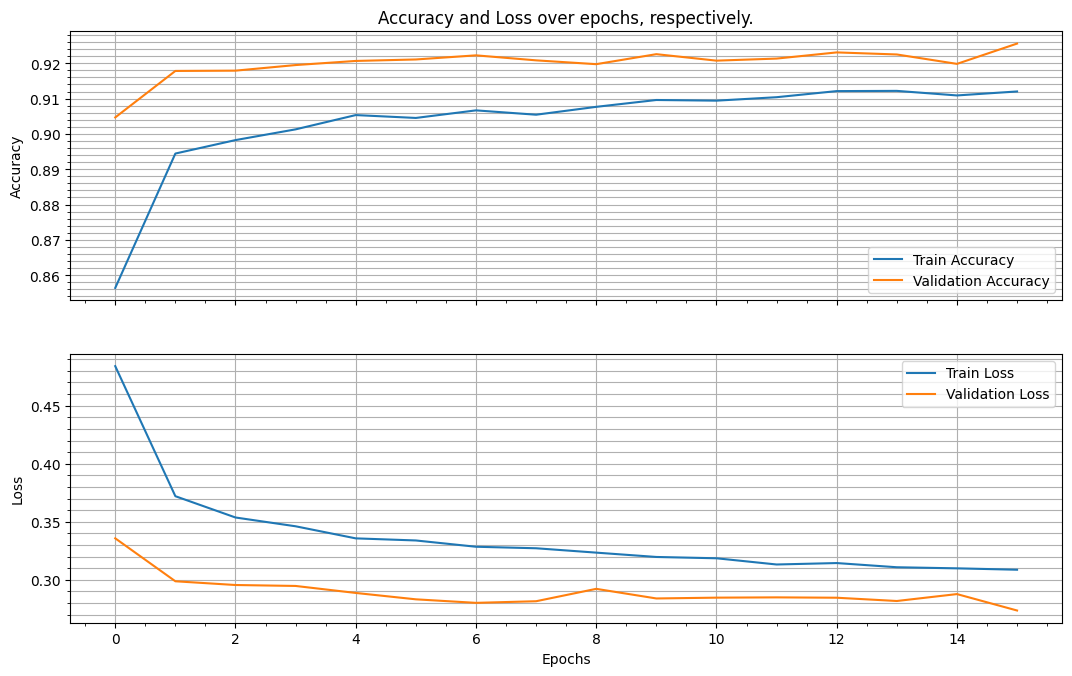

In [81]:
# Plot accuracy over epochs
fig_path = './figs/MNIST'

# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyQAT.history['accuracy'], label='Train Accuracy')
ax1.plot(historyQAT.history['val_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyQAT.history['loss'], label='Train Loss')
ax2.plot(historyQAT.history['val_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAT_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

### Metricas

313/313 [==============================] - 0s 593us/step


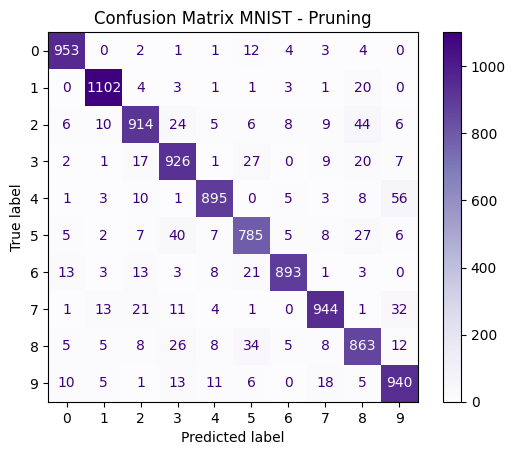

In [82]:
y_pred_probs = modelQAT.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - Pruning')
plt.show()

## Quantization-aware prunning

Quantization-aware pruning (QAP) combina pruning con quantization-aware training. El objetivo es reducir el tamaño del modelo luego de cuantizarlo, para obtener una red más eficiente sin sacrificar precisión.

In [ ]:
final_sparsity = 0.3

pruning_params = {
                'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
                initial_sparsity=0, final_sparsity=final_sparsity, begin_step=0, end_step=3000
                )
            }

In [67]:
## Estrategia de cuantización

## Definición del número de bits para kernel, bias, y activación.
# 8-bits

kernelQ = "quantized_bits(8,4,alpha=1)"
biasQ = "quantized_bits(8, 4,alpha=1)"
activationQ = 'quantized_bits(8, 4)'

modelQ = Sequential(
            [   
                Flatten(input_shape=(28, 28)),
                QDense(100, name='fc1',
                        kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation= activationQ ,  name='relu1'),

                Dropout(0.1),

                QDense(50, name='fc2',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu2'), 
                Dropout(0.1),
                

                QDense(20, name='fc3',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu3'), 
                
                Dropout(0.1),
                
                QDense(10, name='output',
                        kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                        kernel_initializer='lecun_uniform'),
                Activation(activation='softmax', name='softmax')
               
            ],

            name="quantizedModel",
        )

/Users/denisegayet/.venv_py39/lib/python3.9/site-packages/keras/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [69]:
# Entrenamiento


epochs = 16
lr = 0.001
loss = 'categorical_crossentropy'
op = Adam(lr)
metrics = ['accuracy']
batch = 64
val_split = 0.2


modelQAP = tfmot.sparsity.keras.prune_low_magnitude(modelQ, **pruning_params)

modelQAP.compile(optimizer=op, loss=loss, metrics=metrics)
                
historyQAP = modelQAP.fit(x_train_norm, y_train,
                validation_split = val_split,
                epochs=epochs,
                batch_size = batch,
                callbacks = [tfmot.sparsity.keras.UpdatePruningStep()],
                verbose=1
                )

Epoch 1/16
750/750 [==============================] - 2s 2ms/step - loss: 0.6168 - accuracy: 0.8163 - val_loss: 0.3928 - val_accuracy: 0.8896
Epoch 2/16
750/750 [==============================] - 1s 2ms/step - loss: 0.5532 - accuracy: 0.8356 - val_loss: 0.3977 - val_accuracy: 0.8838
Epoch 3/16
750/750 [==============================] - 1s 1ms/step - loss: 0.5232 - accuracy: 0.8455 - val_loss: 0.3861 - val_accuracy: 0.8877
Epoch 4/16
750/750 [==============================] - 1s 2ms/step - loss: 0.4933 - accuracy: 0.8546 - val_loss: 0.3693 - val_accuracy: 0.8899
Epoch 5/16
750/750 [==============================] - 1s 2ms/step - loss: 0.4829 - accuracy: 0.8561 - val_loss: 0.3867 - val_accuracy: 0.8854
Epoch 6/16
750/750 [==============================] - 1s 2ms/step - loss: 0.4675 - accuracy: 0.8628 - val_loss: 0.3657 - val_accuracy: 0.8957
Epoch 7/16
750/750 [==============================] - 1s 2ms/step - loss: 0.4652 - accuracy: 0.8623 - val_loss: 0.3435 - val_accuracy: 0.9019
Epoch 

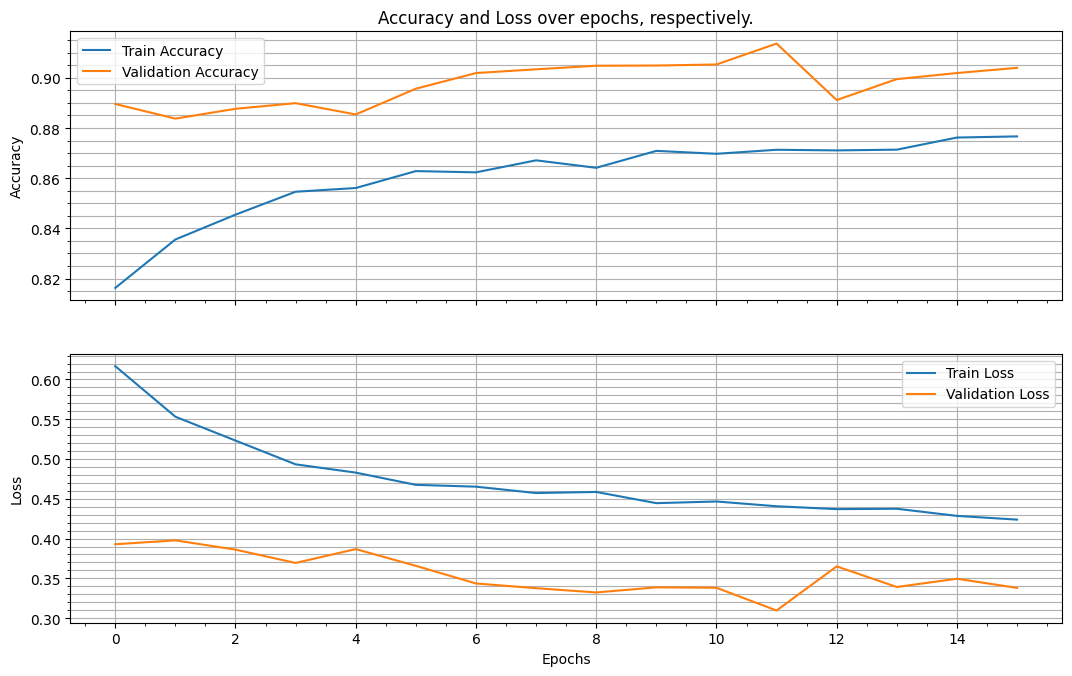

In [72]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyQAP.history['accuracy'], label='Train Accuracy')
ax1.plot(historyQAP.history['val_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyQAP.history['loss'], label='Train Loss')
ax2.plot(historyQAP.history['val_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

313/313 [==============================] - 0s 651us/step


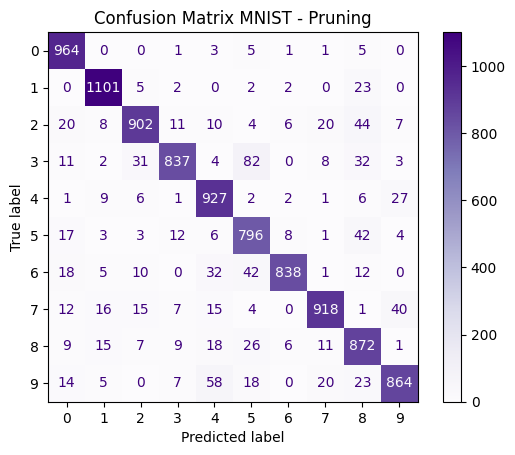

In [71]:
## metrics

y_pred_probs = modelQAP.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - Pruning')
plt.show()


#### 📝 Ejercicio: 

- Modificar el numero de bits (4, 8, 16, 32) y reportar las metricas de cada modelo, considerando QAT y QAP. Que conclusion puede obtener? 

- Modificar la arquitectura MLP (aumentando o disminuyendo capas) y reemplazando la capa _Flatten_ por _Dense_ . 

---

A mayor precisión, mejor accuracy, no hay tantos saltos en el loss porque al tener mejor precisión, los saltos de los pesos es menor.

## Knowledge Distillation

In [83]:
# Cargar dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0            # Normalización

x_train = x_train.reshape(-1, 28 * 28)                       # Aplanar imágenes
x_test = x_test.reshape(-1, 28 * 28)

y_train = to_categorical(y_train, num_classes=10, dtype=int)
y_test = to_categorical(y_test, num_classes=10, dtype=int)

In [90]:
def build_teacher():
    model = keras.Sequential([
        Dense(512, activation="relu", input_shape=(28 * 28,)),
        Dense(256, activation="relu"),
        Dense(10,  activation="softmax")  
    ])
    return model

def build_student():
    model = keras.Sequential([
        Dense(5, activation="relu", input_shape=(28 * 28,)),  
        Dense(7, activation="relu"),
        Dense(10, activation="softmax")  # Softmax en la salida
    ])
    return model

In [91]:
# Definir el modelo Teacher (MLP grande) 
hparamsT = {
    'batch-size' : 128,
    'epochs' : 16,
    'learning-rate' : 0.001
}



# Compilar y entrenar el modelo Teacher
teacher = build_teacher()
teacher.summary()

teacher.compile(optimizer="adam", 
                loss="categorical_crossentropy", 
                metrics=["accuracy"])
historyT = teacher.fit(x_train, y_train,
                       epochs=hparamsT['epochs'],
                       batch_size=hparamsT['batch-size'],
                       validation_data=(x_test, y_test))

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 512)               401920    
                                                                 
 dense_19 (Dense)            (None, 256)               131328    
                                                                 
 dense_20 (Dense)            (None, 10)                2570      
                                                                 
Total params: 535,818
Trainable params: 535,818
Non-trainable params: 0
_________________________________________________________________
Epoch 1/16
469/469 [==============================] - 2s 3ms/step - loss: 0.2271 - accuracy: 0.9329 - val_loss: 0.1103 - val_accuracy: 0.9649
Epoch 2/16
469/469 [==============================] - 1s 3ms/step - loss: 0.0829 - accuracy: 0.9744 - val_loss: 0.0797 - val_accuracy: 0.9760
Epoch 3/16
469/469 [========

In [92]:
# Definir el modelo Student (MLP más pequeño)
student = build_student()

In [93]:
train_labels = np.argmax(y_train, axis=1)

distilledMLP = Distiller(student=student, teacher=teacher)

In [94]:
distilledMLP.student.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 5)                 3925      
                                                                 
 dense_22 (Dense)            (None, 7)                 42        
                                                                 
 dense_23 (Dense)            (None, 10)                80        
                                                                 
Total params: 4,047
Trainable params: 4,047
Non-trainable params: 0
_________________________________________________________________


In [95]:
hparamsS = {
    'epochs' : 32,
    'batch-size' : 64,
    'learning-rate' : 0.0001,
    'val-split' : 0.2,
}

adam = Adam(hparamsS['learning-rate'])
distilledMLP.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1, 
        temperature=10,
    )

historyS = distilledMLP.fit(x_train, train_labels, 
                           validation_split=hparamsS['val-split'],
                           batch_size = hparamsS['batch-size'], 
                           epochs= hparamsS['epochs'])

Epoch 1/32


/Users/denisegayet/.venv_py39/lib/python3.9/site-packages/keras/backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


750/750 [==============================] - 2s 3ms/step - sparse_categorical_accuracy: 0.2486 - student_loss: 2.0536 - distillation_loss: 4.4071e-04 - val_sparse_categorical_accuracy: 0.4621 - val_student_loss: 1.7285
Epoch 2/32
750/750 [==============================] - 1s 1ms/step - sparse_categorical_accuracy: 0.5014 - student_loss: 1.5551 - distillation_loss: 3.5064e-04 - val_sparse_categorical_accuracy: 0.5342 - val_student_loss: 1.3236
Epoch 3/32
750/750 [==============================] - 1s 1ms/step - sparse_categorical_accuracy: 0.5864 - student_loss: 1.2594 - distillation_loss: 2.8803e-04 - val_sparse_categorical_accuracy: 0.6370 - val_student_loss: 1.0516
Epoch 4/32
750/750 [==============================] - 1s 1ms/step - sparse_categorical_accuracy: 0.6605 - student_loss: 1.0675 - distillation_loss: 2.4822e-04 - val_sparse_categorical_accuracy: 0.6916 - val_student_loss: 0.8593
Epoch 5/32
750/750 [==============================] - 1s 2ms/step - sparse_categorical_accuracy: 0.

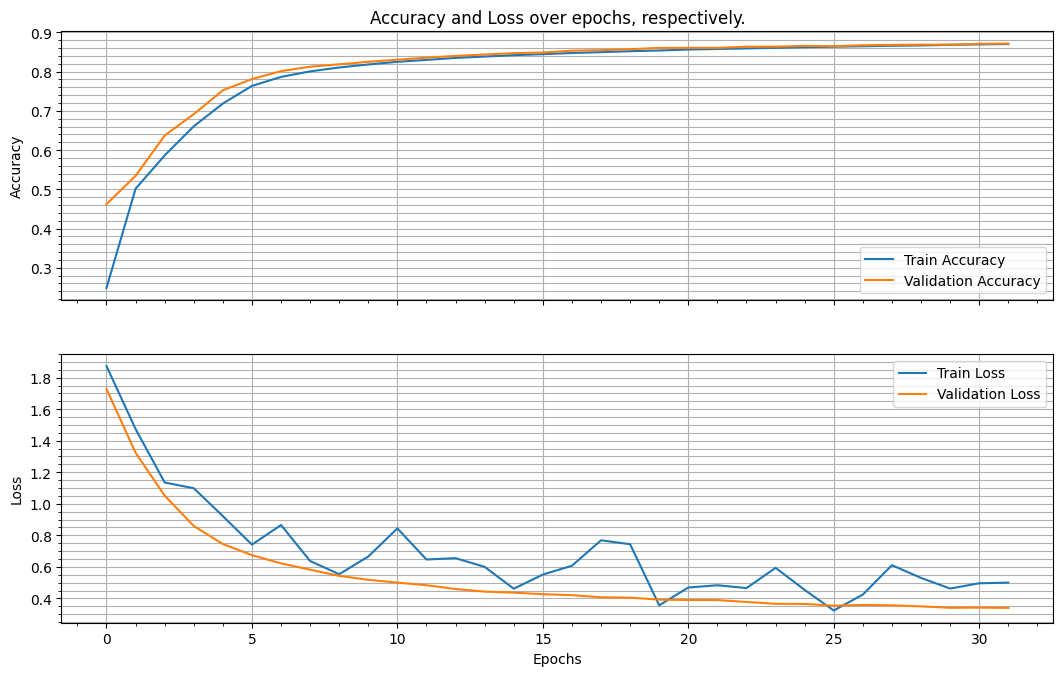

In [96]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyS.history['sparse_categorical_accuracy'], label='Train Accuracy')
ax1.plot(historyS.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyS.history['student_loss'], label='Train Loss')
ax2.plot(historyS.history['val_student_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

313/313 [==============================] - 0s 264us/step


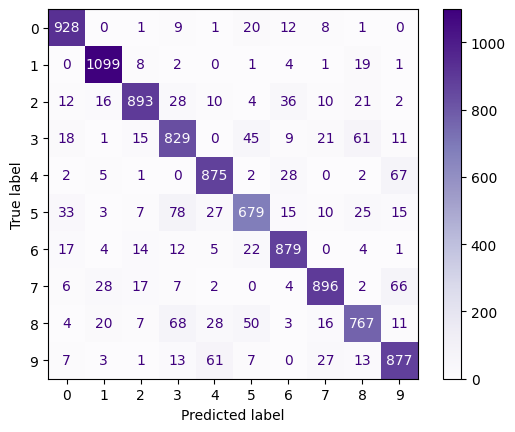

In [101]:
#### Métricas
y_pred_probs = distilledMLP.student.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.show()


In [102]:
distilledMLP.student.save("models/mnistKD.h5")